# Theory-validation experiment: kernel gradient descent on $S^1$

## Goal

The purpose of this experiment is to validate the analytic NTK theory on the circle $S^1$ in a clean, deterministic setting.

We work with the infinite-width kernel directly, not a finite-width neural network. The main question is:

- does the discrete kernel gradient descent dynamics on a fine grid behave the way the continuum Fourier theory predicts?

More specifically, we want to check that:

1. the empirical eigenvalues of the discrete kernel matrix match the analytic continuum Fourier eigenvalues up to the expected discretization scaling,
2. the residual decays mode-by-mode at rates predicted by those eigenvalues,
3. sampled Fourier modes on the circle behave like approximate eigendirections of the kernel matrix.

---

## Setup

We consider inputs on the unit circle,
$$
x(\gamma) = (\cos \gamma, \sin \gamma), \qquad \gamma \in [0,2\pi),
$$
and use an evenly spaced grid of training angles
$$
\gamma_j = \frac{2\pi j}{n}, \qquad j=0,\dots,n-1.
$$

The target function is a finite Fourier mixture with a few selected modes, for example
$$
f^*(\gamma)
=
a_1 \cos(k_1 \gamma)
+
a_2 \cos(k_2 \gamma)
+
a_3 \cos(k_3 \gamma).
$$

We then build the analytic infinite-width NTK Gram matrix
$$
\Theta_{XX} = [\Theta(\gamma_i,\gamma_j)]_{i,j=1}^n
$$
using the closed-form kernel on $S^1$.

For the theory-validation run, we use kernel gradient descent directly in prediction space:
$$
y_{\mathrm{pred},t+1}
=
y_{\mathrm{pred},t}
-
\eta\,\Theta_{XX}(y_{\mathrm{pred},t}-y),
$$
with residual
$$
r_t = y_{\mathrm{pred},t}-y.
$$

Equivalently,
$$
r_{t+1} = (I-\eta \Theta_{XX})r_t.
$$

This is the exact discrete-time linear dynamics induced by the frozen infinite-width kernel.

---

This run is designed for theory validation rather than realism.

- We use an evenly spaced grid on the circle so that the discrete kernel matrix approximates the continuum convolution operator well.
- We use a small step size $\eta$ so the discrete dynamics resemble gradient flow.
- We use only a few Fourier modes in the target so the spectral behavior is easy to interpret.
- We analyze the exact discrete kernel matrix used in the experiment, so we can compare observed decay against the exact finite-$n$ prediction.

---

## What we expect theoretically

In the continuum, the operator
$$
(Tf)(\phi)
=
\int \Theta(\phi-\psi) f(\psi)\,\frac{d\psi}{2\pi}
$$
is convolutional on $S^1$, so Fourier modes are eigenfunctions.

If $\lambda_k$ is the eigenvalue associated with mode $k$, then that component of the residual should decay at a rate determined by $\lambda_k$.

In the discrete finite-$n$ experiment, if
$$
\Theta_{XX} = Q \Lambda Q^\top,
$$
then the residual coefficients in the empirical eigenbasis,
$$
\alpha_t = Q^\top r_t,
$$
satisfy
$$
\alpha_k(t+1) = (1-\eta \lambda_k)\alpha_k(t).
$$

So there are two levels of validation:

1. **Exact discrete validation:** compare observed decay against the eigenvalues of the actual matrix $\Theta_{XX}$.
2. **Continuum validation:** compare the discrete spectrum and Fourier-mode behavior against the analytic continuum Fourier theory.

---

## Saved artifacts

The experiment saves several artifacts that together describe the full run.

### `training_task.npz`

This contains the training geometry and target:
- `gamma_train`: evenly spaced angles on the circle
- `X_train`: corresponding 2D circle coordinates
- `y_train`: target values on the grid

This defines the discrete problem we are solving.

---

### `kernel_objects.npz`

This contains the fixed kernel objects:
- `theta_xx`: the discrete NTK Gram matrix
- `evals_emp`: empirical eigenvalues of `theta_xx`
- `evecs`: empirical eigenvectors of `theta_xx`

This is the spectral description of the exact finite-$n$ linear operator used in the dynamics.

---

### `kernel_dynamics.npz`

This contains the kernel gradient descent trajectory:
- `y_pred`: prediction vectors across time
- `r`: residual vectors across time
- `loss`: least-squares loss across time
- `eta`: the step size used

This is the actual observed dynamics we want to analyze.

---

### `mode_projections.npz`

This contains precomputed mode decompositions of the residual:
- `eig_coeffs`: projections of the residual onto empirical kernel eigenvectors
- `cos_k`, `sin_k`: projections of the residual onto sampled Fourier modes

These are the main quantities for studying spectral bias and comparing theory to practice.

---

### `continuum_spectrum.npz`

For the bias kernel, this contains:
- `ks_compare`: mode indices used for comparison
- `lambda_cont`: analytic continuum Fourier eigenvalues
- `lambda_disc_pred`: predicted discrete eigenvalues, using the scaling
  $$
  \lambda_k^{\mathrm{disc}} \approx n \lambda_k^{\mathrm{cont}}
  $$

This gives the continuum theoretical benchmark.

---

## What we will track in this notebook

In the analysis below, we will focus on three main comparisons.

### 1. Discrete spectrum vs continuum spectrum
We compare the empirical eigenvalues of the kernel matrix with the analytic continuum Fourier eigenvalues after the appropriate scaling.

This checks whether the discrete circle kernel is approximating the continuum operator correctly.

### 2. Observed eigenmode decay vs predicted eigenmode decay
Using the empirical eigenvalues and eigenvectors of `theta_xx`, we compare:
- the observed decay of each residual coefficient,
- the ideal decay
  $$
  \alpha_k(t) = (1-\eta\lambda_k)^t \alpha_k(0).
  $$

This is the most exact validation of the kernel-GD implementation.

### 3. Fourier-mode decay
We also inspect projections onto sampled Fourier modes such as $\cos(k\gamma)$.

This connects the finite discrete run back to the continuum Fourier picture on $S^1$ and makes the spectral-bias interpretation more intuitive.

---

## Summary

This experiment gives us a controlled setting in which:

- the kernel is known analytically,
- the discrete dynamics are exactly linear,
- the continuum theory is explicit,
- and the finite-$n$ approximation can be checked directly.

So the notebook analysis is not trying to prove the theory; it is validating that the implementation and the discrete dynamics behave exactly as the spectral theory predicts.

In [40]:
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print("Project root added to sys.path:", ROOT)

from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
import jax.numpy as jnp
from utils.artifacts_io import latest_run_dir, load_manifest, npz

Project root added to sys.path: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments


In [41]:
BASE = "../results"

EXPERIMENTS = {
    "grid_1024": "kernel_gd_circle_theory",
    "grid_4096": "kernel_gd_circle_theory_finegrid",
}

plot_path = Path("plots") / "kernel_experiments_comparison/"
plot_path.mkdir(exist_ok=True)

def load_experiment(exp_name: str, base: str = BASE) -> dict:
    run_dir = latest_run_dir(base, exp_name)
    if run_dir is None:
        raise FileNotFoundError(f"No run found for experiment '{exp_name}' in {base}")

    manifest = load_manifest(run_dir)

    data = {
        "run_dir": run_dir,
        "manifest": manifest,
        "training_task": npz(run_dir, manifest["training_task"]),
        "kernel_objects": npz(run_dir, manifest["kernel_objects"]),
        "kernel_dynamics": npz(run_dir, manifest["kernel_dynamics"]),
        "mode_projections": npz(run_dir, manifest["mode_projections"]),
    }

    if "continuum_spectrum" in manifest:
        data["continuum_spectrum"] = npz(run_dir, manifest["continuum_spectrum"])

    if "final_prediction" in manifest:
        data["final_prediction"] = npz(run_dir, manifest["final_prediction"])

    return data


runs = {label: load_experiment(exp_name) for label, exp_name in EXPERIMENTS.items()}

In [42]:
def summarize_run(label: str, run: dict) -> None:
    meta = run["manifest"].get("meta", {})
    print(f"=== {label} ===")
    print("run_dir:", run["run_dir"])
    print("kernel:", meta.get("kernel"))
    print("init:", meta.get("init"))
    print("n_train:", meta.get("n_train"))
    print("steps:", meta.get("steps"))
    print("eta:", meta.get("eta"))
    print("target_Ks:", meta.get("target_Ks"))
    print("target_amps:", meta.get("target_amps"))
    print()


for label, run in runs.items():
    summarize_run(label, run)

=== grid_1024 ===
run_dir: ../results/kernel_gd_circle_theory/kernel_gd_results_grid_1024
kernel: bias
init: zero
n_train: 1024
steps: 1000
eta: 8.814315343321457e-05
target_Ks: [0, 1, 2, 3]
target_amps: [1, 0.9, 0.5, 0.35]

=== grid_4096 ===
run_dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_gd_circle_theory_finegrid/20260317-133008-d85c81be
kernel: bias
init: zero
n_train: 4096
steps: 1000
eta: 2.2035809697111986e-05
target_Ks: [0, 1, 2, 3]
target_amps: [1, 0.9, 0.5, 0.35]



In [43]:
def unpack(run: dict) -> dict:
    tt = run["training_task"]
    ko = run["kernel_objects"]
    kd = run["kernel_dynamics"]
    mp = run["mode_projections"]

    n = len(tt["gamma_train"])

    out = {
        "n": n,
        "gamma": tt["gamma_train"],
        "y": tt["y_train"],
        "theta_xx": ko["theta_xx"],
        "evals_emp": ko["evals_emp"],
        "evecs": ko["evecs"],
        "y_pred": kd["y_pred"],
        "r": kd["r"],
        "loss": kd["loss"],
        "eta": float(np.ravel(kd["eta"])[0]),
        "mode_projections": mp,
    }

    if "final_prediction" in run:
        fp = run["final_prediction"]
        out["y_pred_final"] = fp["y_pred_final"]
        out["r_final"] = fp["r_final"]
    else:
        out["y_pred_final"] = kd["y_pred"][-1]
        out["r_final"] = kd["r"][-1]

    return out


A = {label: unpack(run) for label, run in runs.items()}

for label, a in A.items():
    print(label, "n =", a["n"], "eta =", a["eta"])

grid_1024 n = 1024 eta = 8.814315343321457e-05
grid_4096 n = 4096 eta = 2.2035809697111986e-05


In [44]:
for label, arr in A.items():
    print(f"=== {label} ===")
    print("n_train:", len(arr["gamma"]))
    print("steps:", len(arr["loss"]) - 1)
    print("eta:", arr["eta"])
    print("target range:", (arr["y"].min(), arr["y"].max()))
    print()

=== grid_1024 ===
n_train: 1024
steps: 1000
eta: 8.814315343321457e-05
target range: (np.float32(0.25000003), np.float32(2.75))

=== grid_4096 ===
n_train: 4096
steps: 1000
eta: 2.2035809697111986e-05
target range: (np.float32(0.25000003), np.float32(2.75))



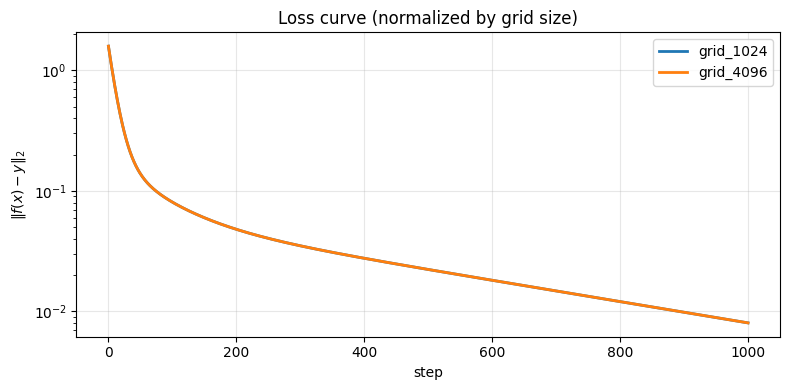

In [45]:
save_path = plot_path / "loss_curve_grid.png"
plt.figure(figsize=(8, 4))

for label in ["grid_1024", "grid_4096"]:
    residual = np.linalg.norm(A[label]["r"], axis=1) ** 2 / A[label]['n']
    plt.plot(residual, linewidth=2, label=label)

plt.yscale("log")
plt.xlabel("step")
plt.ylabel(r'$\|f(x) - y\|_2$')
plt.title("Loss curve (normalized by grid size)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

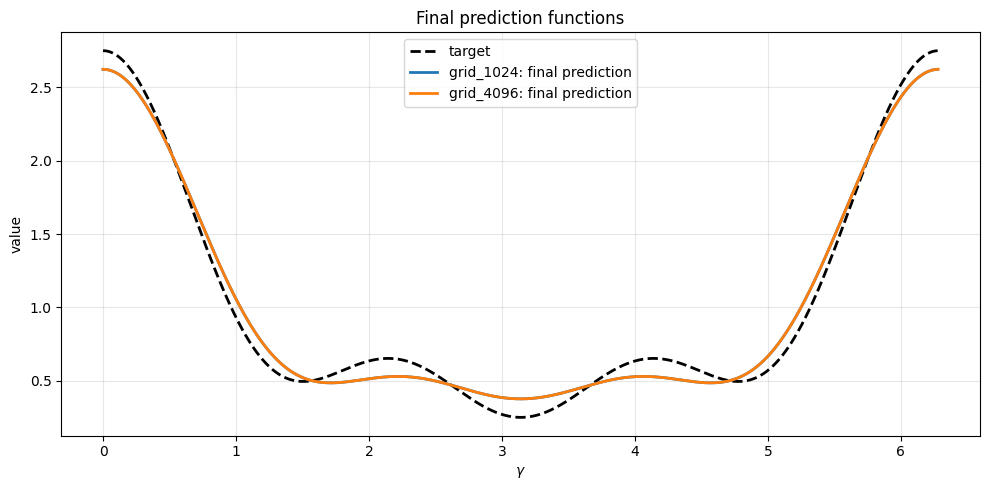

In [46]:
save_path = plot_path / "final_predictions_grid.png"
plt.figure(figsize=(10, 5))

# target
plt.plot(
    A["grid_1024"]["gamma"],
    A["grid_1024"]["y"],
    "k--",
    linewidth=2,
    label="target",
)

for label in ["grid_1024", "grid_4096"]:
    plt.plot(
        A[label]["gamma"],
        A[label]["y_pred_final"],
        linewidth=2,
        label=f"{label}: final prediction",
    )

plt.xlabel(r"$\gamma$")
plt.ylabel("value")
plt.title("Final prediction functions")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

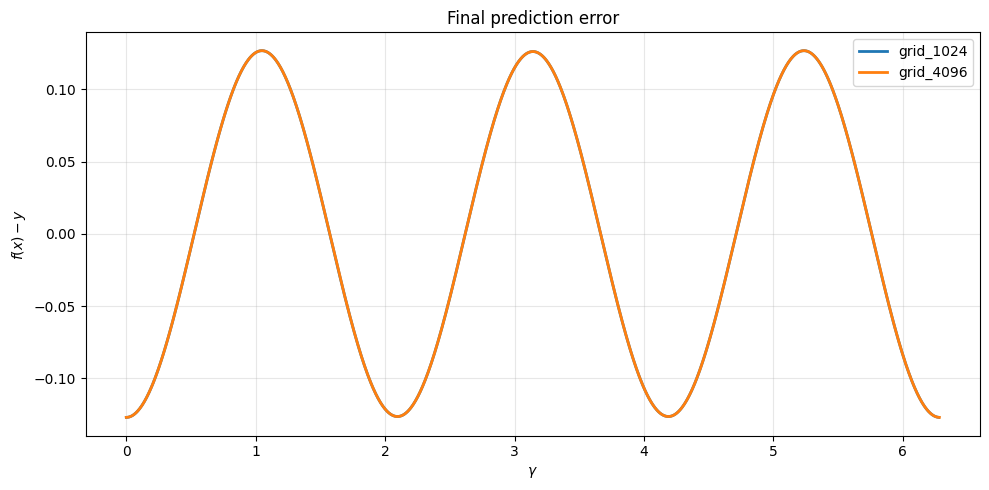

In [47]:
save_path = plot_path / "prediction_error_grid.png"
plt.figure(figsize=(10, 5))

for label in ["grid_1024", "grid_4096"]:
    gamma = A[label]["gamma"]
    err = A[label]["y_pred_final"] - A[label]["y"]
    plt.plot(gamma, err, linewidth=2, label=label)

plt.xlabel(r"$\gamma$")
plt.ylabel(r"$f(x) - y$")
plt.title("Final prediction error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

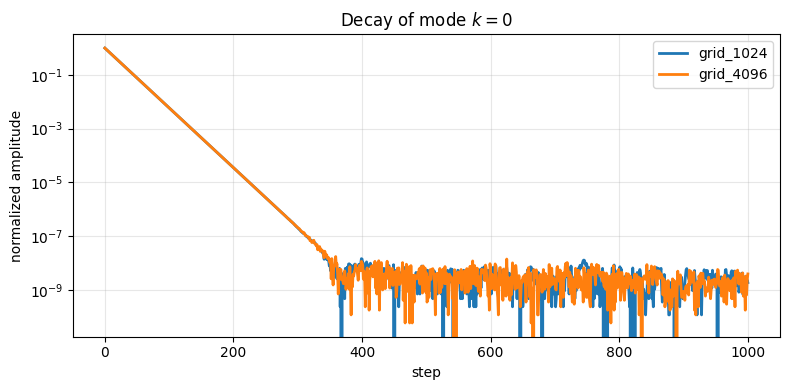

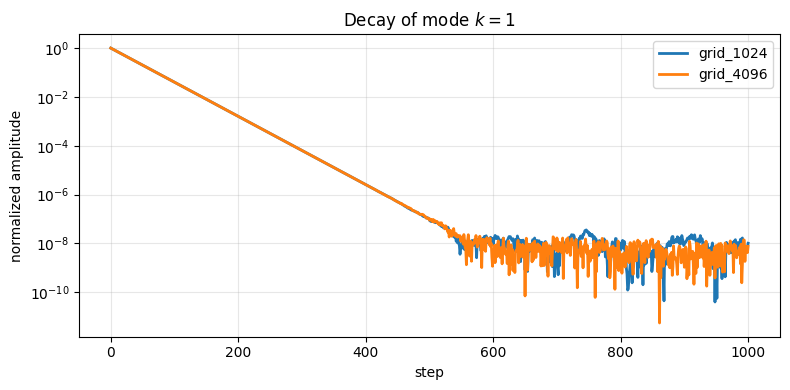

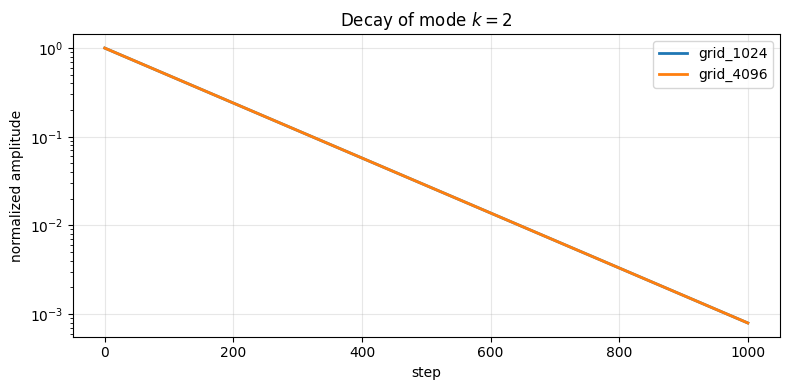

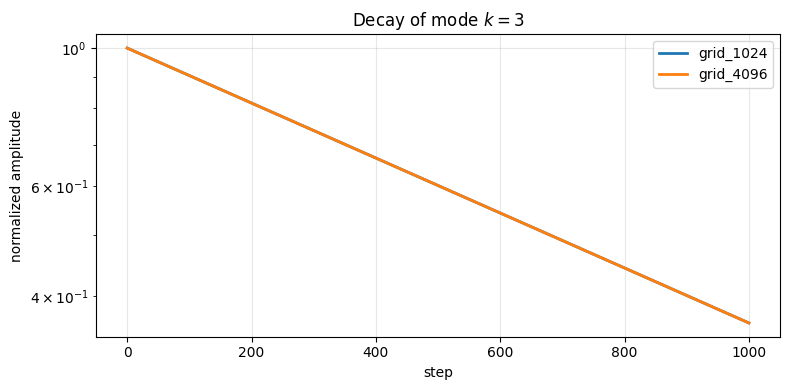

In [53]:
modes = [0, 1, 2, 3]

save_path = lambda k: plot_path / f"residual_decay_grid_mode_{k}.png"

for k in modes:
    plt.figure(figsize=(8, 4))

    for label in ["grid_1024", "grid_4096"]:
        vals = np.abs(np.asarray(A[label]["mode_projections"][f"cos_{k}"]))
        vals = vals / max(vals[0], 1e-14)
        plt.plot(vals, linewidth=2, label=label)

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("normalized amplitude")
    plt.title(rf"Decay of mode $k={k}$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path(k), dpi=300)
    plt.show()

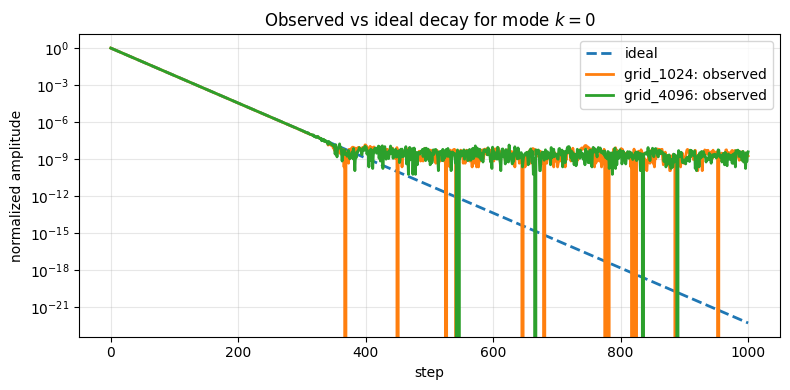

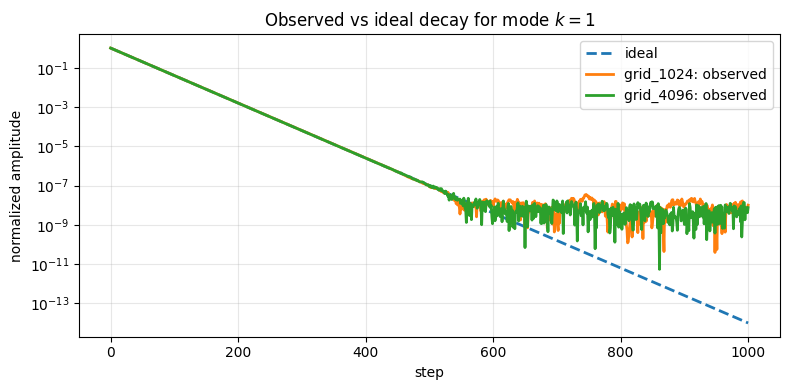

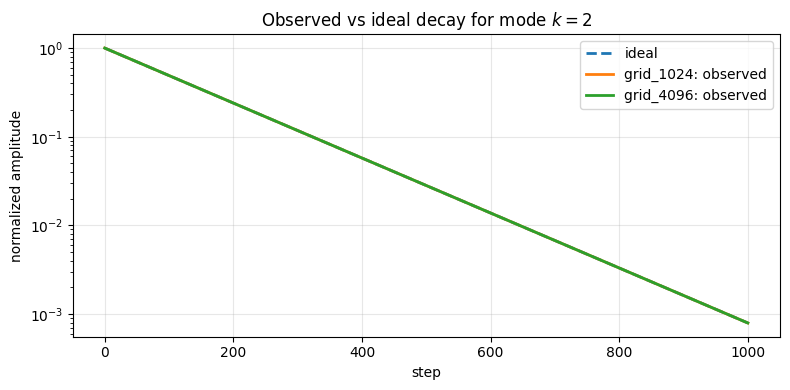

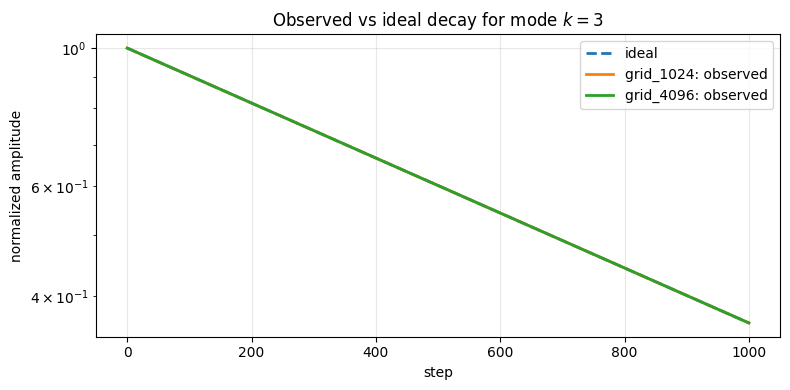

In [20]:
modes = [0, 1, 2, 3]
save_path = lambda k: plot_path / f"observed_vs_ideal_residual_decay_grid_mode_{k}.png"

for k in modes:
    plt.figure(figsize=(8, 4))
    ideal_plotted = False
    for label in ["grid_1024", "grid_4096"]:
        obs = np.abs(np.asarray(A[label]["mode_projections"][f"cos_{k}"]))
        obs = obs / max(obs[0], 1e-14)

        cs = runs[label]["continuum_spectrum"]
        lam_map = {
            int(kk): float(lam)
            for kk, lam in zip(cs["ks_compare"], cs["lambda_disc_pred"])
        }
        eta = A[label]["eta"]
        pred = np.abs(1.0 - eta * lam_map[k]) ** np.arange(len(obs))

        if not ideal_plotted:
            plt.plot(pred, "--", linewidth=2, label=f"ideal")
            ideal_plotted=True

        plt.plot(obs, linewidth=2, label=f"{label}: observed")
        

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("normalized amplitude")
    plt.title(rf"Observed vs ideal decay for mode $k={k}$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path(k), dpi=300)
    plt.show()

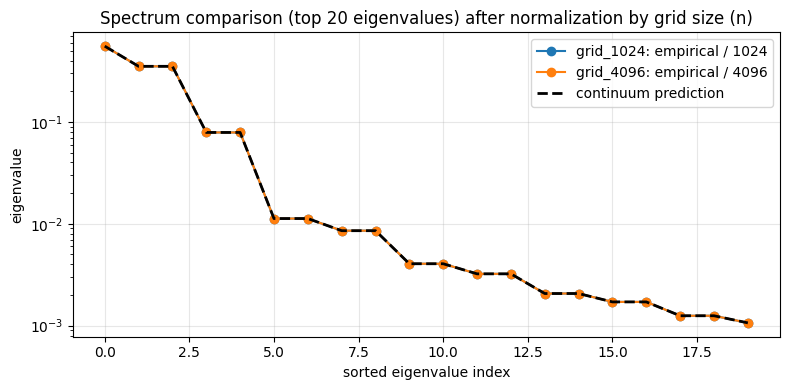

In [22]:
plt.figure(figsize=(8, 4))
save_path = plot_path / "spectrum_comparison_grid.png"

for label in ["grid_1024", "grid_4096"]:
    n = A[label]["n"]
    evals_norm = A[label]["evals_emp"] / n
    plt.plot(evals_norm[:20], marker="o", linewidth=1.5, label=f"{label}: empirical / {n}")

# continuum reference from one of the runs
cs = runs["grid_1024"]["continuum_spectrum"]
ks = cs["ks_compare"]
lam_cont = cs["lambda_cont"]

# with multiplicity
pred_with_mult = [lam_cont[0]]
for k in ks[1:]:
    pred_with_mult.extend([lam_cont[int(k)], lam_cont[int(k)]])
pred_with_mult = np.asarray(pred_with_mult)

plt.plot(pred_with_mult[:20], "k--", linewidth=2, label="continuum prediction")

plt.xlabel("sorted eigenvalue index")
plt.ylabel("eigenvalue")
plt.title("Spectrum comparison (top 20 eigenvalues) after normalization by grid size (n)")
plt.grid(True, alpha=0.3)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

In [55]:
BASE = "../results"

EXPERIMENTS = {
    "baseline": "kernel_gd_circle_theory",
    "highfreq_heavy": "kernel_gd_circle_theory_ampswap",
}

def cosine_formula_from_manifest(manifest: dict) -> str:
    meta = manifest["meta"]
    ks = meta["target_Ks"]
    amps = meta["target_amps"]

    terms = []
    for k, a in zip(ks, amps):
        if k == 0:
            terms.append(f"{a:g}")
        elif k == 1:
            terms.append(f"{a:g} cos(γ)")
        else:
            terms.append(f"{a:g} cos({k}γ)")
    return " + ".join(terms)

runs = {label: load_experiment(exp_name, base=BASE) for label, exp_name in EXPERIMENTS.items()}
A = {label: unpack(run) for label, run in runs.items()}

for label, run in runs.items():
    print(f"{label}:")
    print("  formula:", cosine_formula_from_manifest(run["manifest"]))
    print("  eta:", A[label]["eta"])
    print()

baseline:
  formula: 1 + 0.9 cos(γ) + 0.5 cos(2γ) + 0.35 cos(3γ)
  eta: 8.814315343321457e-05

highfreq_heavy:
  formula: 1 + 0.35 cos(γ) + 0.9 cos(2γ) + 1.4 cos(3γ)
  eta: 8.814315343321457e-05



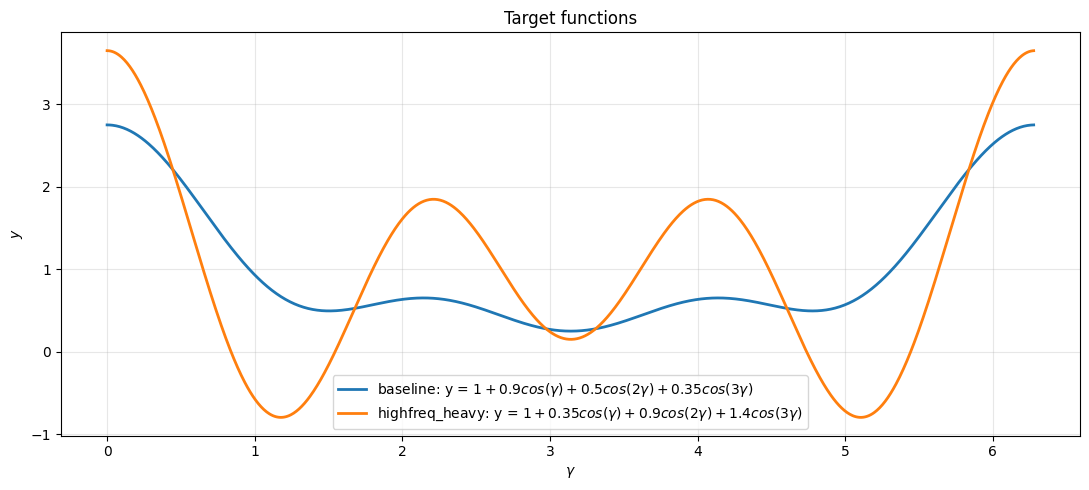

In [56]:
plt.figure(figsize=(11, 5))

save_path = plot_path / "target_functions.png"

for label in ["baseline", "highfreq_heavy"]:
    gamma = A[label]["gamma"]
    y = A[label]["y"]
    formula = cosine_formula_from_manifest(runs[label]["manifest"])

    plt.plot(gamma, y, linewidth=2, label=rf"{label}: y = ${formula}$")

plt.xlabel(r"$\gamma$")
plt.ylabel(r"$y$")
plt.title("Target functions")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

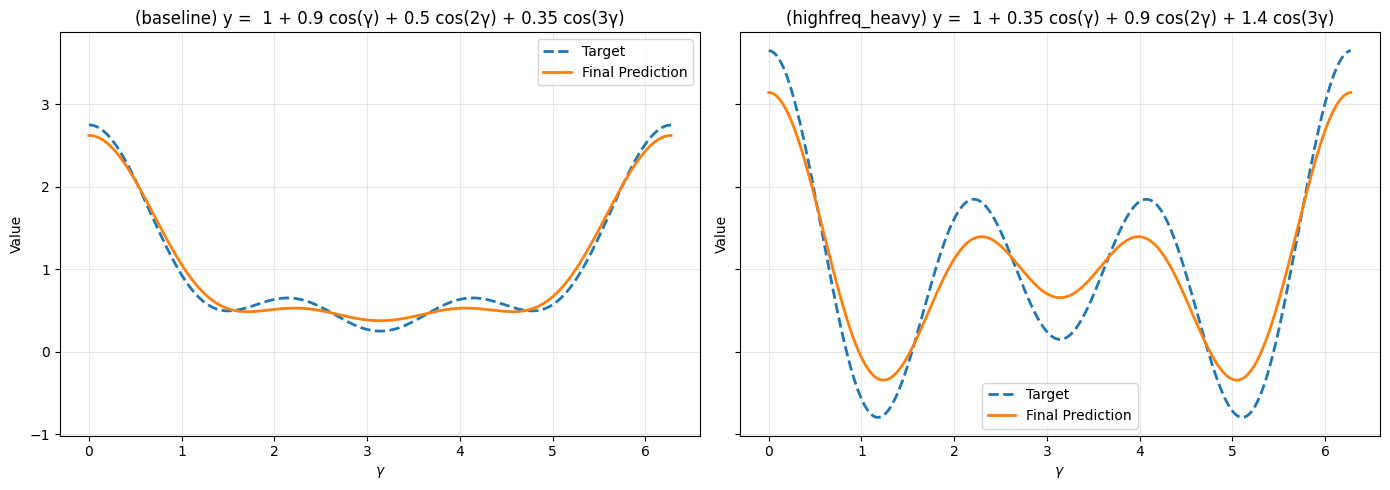

In [57]:
labels = ["baseline", "highfreq_heavy"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

save_path = plot_path / "final_predictions_baseline_vs_highfreq.png"

for i, label in enumerate(labels):
    gamma = A[label]["gamma"]
    y = A[label]["y"]
    y_pred_final = A[label]["y_pred_final"]
    
    # Select the specific subplot axis
    ax = axes[i]
    formula = cosine_formula_from_manifest(runs[label]["manifest"])
    ax.plot(gamma, y, "--", linewidth=2, label="Target")
    ax.plot(gamma, y_pred_final, linewidth=2, label="Final Prediction")
    
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Value")
    ax.set_title(f"({label}) y =  {formula}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

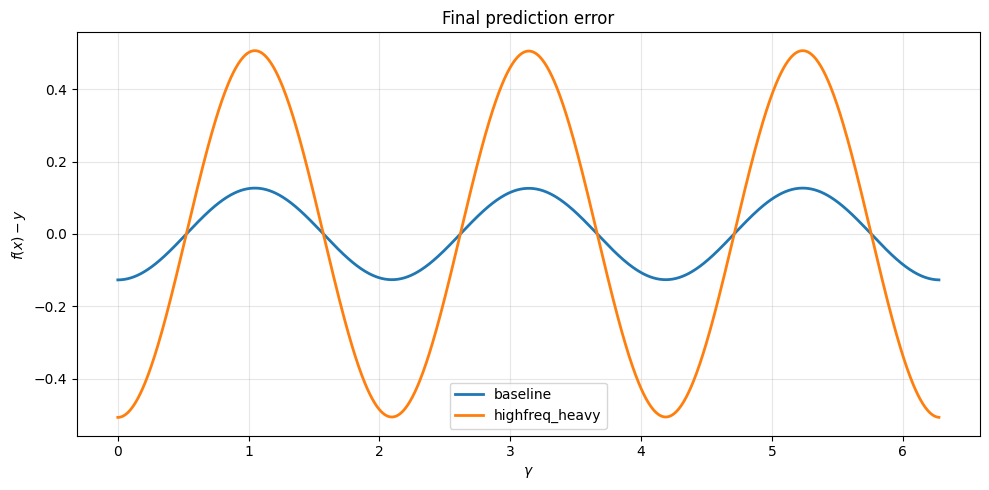

In [58]:
save_path = plot_path / "prediction_error_high_frequency.png"
plt.figure(figsize=(10, 5))

for label in labels:
    gamma = A[label]["gamma"]
    err = A[label]["y_pred_final"] - A[label]["y"]
    plt.plot(gamma, err, linewidth=2, label=label)

plt.xlabel(r"$\gamma$")
plt.ylabel(r"$f(x) - y$")
plt.title("Final prediction error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

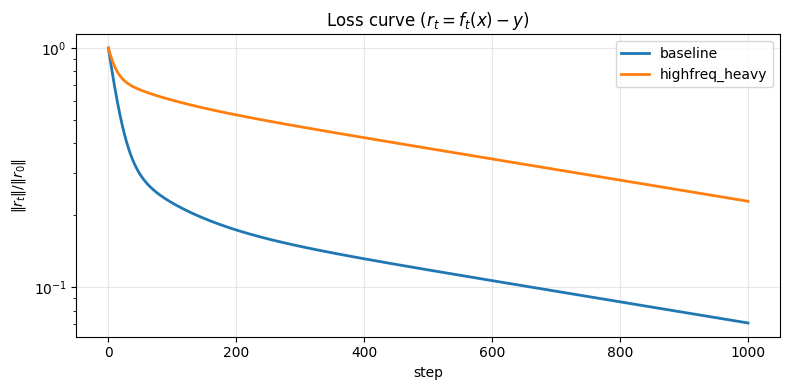

In [34]:
plt.figure(figsize=(8, 4))
save_path = plot_path / "loss_curve_baseline_vs_highfreq.png"
for label in ["baseline", "highfreq_heavy"]:
    r = A[label]["r"]
    rel_error = np.linalg.norm(r, axis=1) / np.linalg.norm(r[0])
    plt.plot(rel_error, linewidth=2, label=label)

plt.yscale("log")
plt.xlabel("step")
plt.ylabel(r"$\|r_t\|/\|r_0\|$")
plt.title(r"Loss curve ($r_t = f_t(x) - y$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

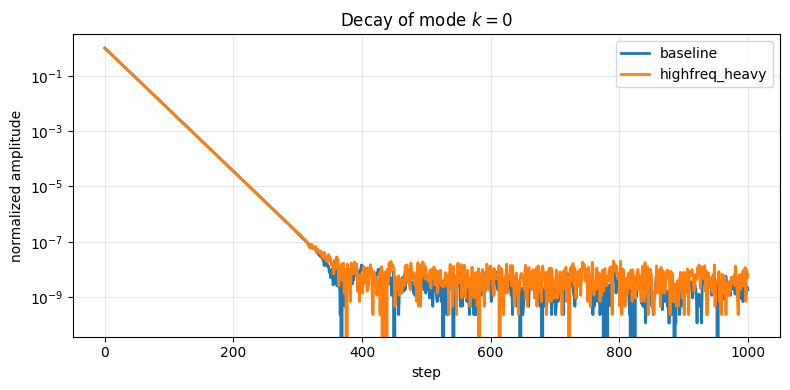

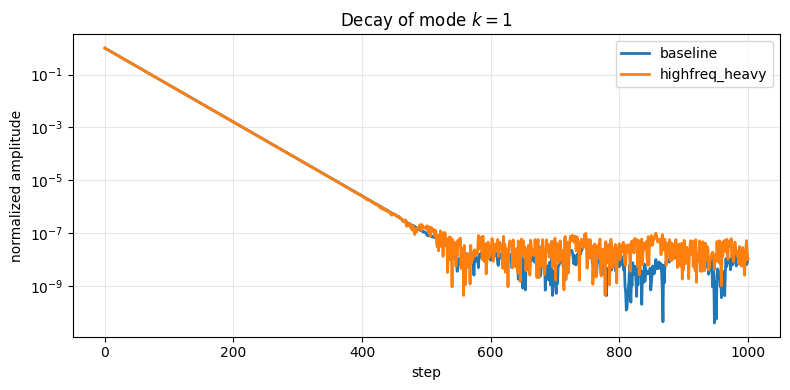

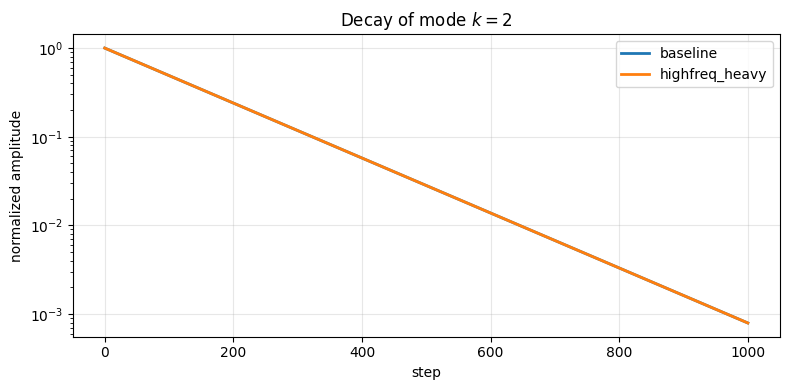

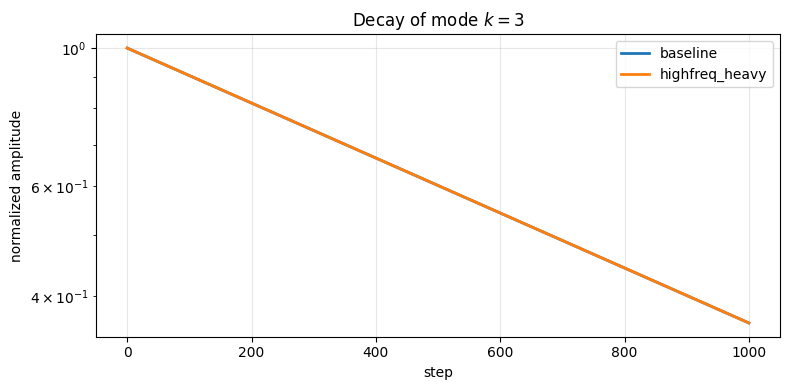

In [35]:
modes = [0, 1, 2, 3]

save_path = lambda k: plot_path / f"residual_decay_mode_{k}.png"

for k in modes:
    plt.figure(figsize=(8, 4))

    for label in ["baseline", "highfreq_heavy"]:
        vals = np.abs(np.asarray(A[label]["mode_projections"][f"cos_{k}"]))
        vals = vals / max(vals[0], 1e-14)
        plt.plot(vals, linewidth=2, label=label)

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("normalized amplitude")
    plt.title(rf"Decay of mode $k={k}$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path(k), dpi=300)
    plt.show()

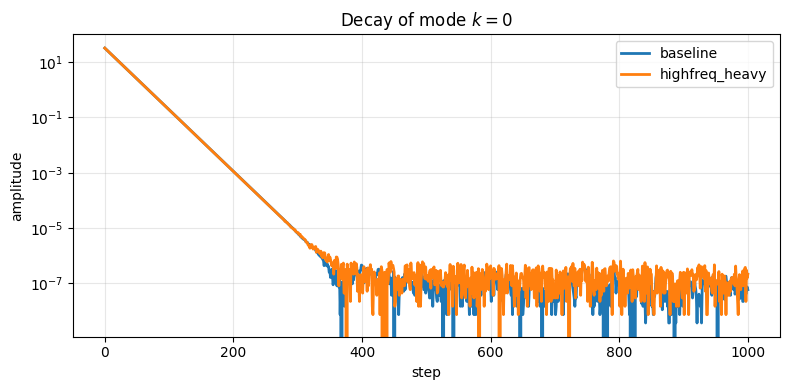

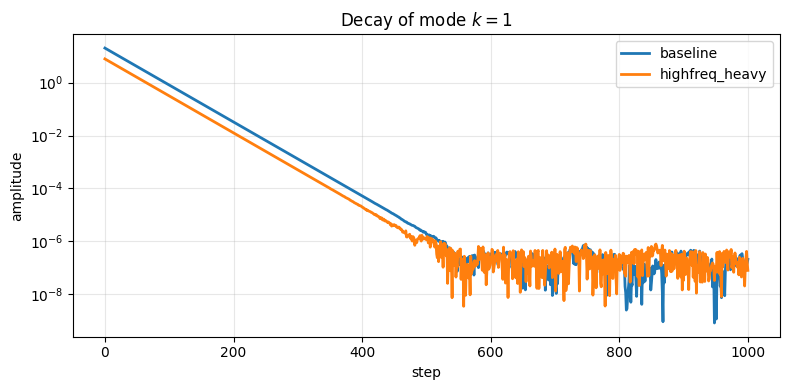

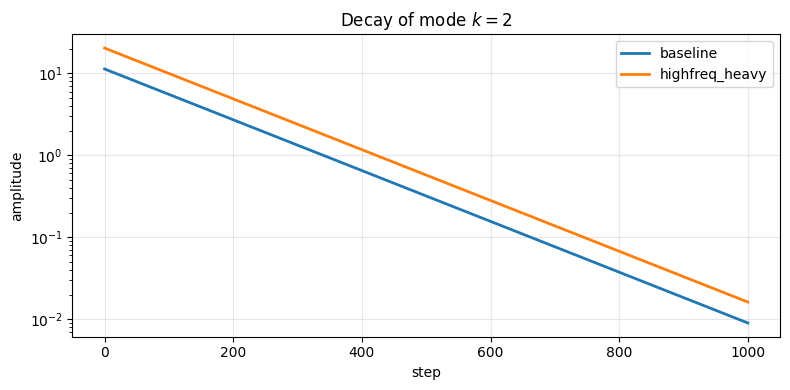

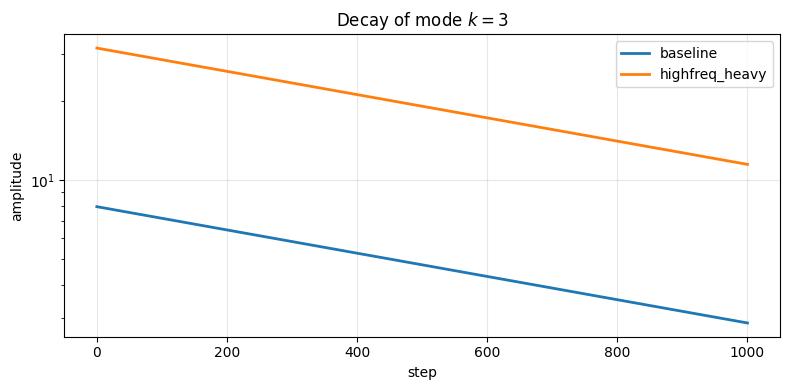

In [39]:
modes = [0, 1, 2, 3]

save_path = lambda k: plot_path / f"unnormalized_residual_decay_mode_{k}.png"

for k in modes:
    plt.figure(figsize=(8, 4))

    for label in ["baseline", "highfreq_heavy"]:
        vals = np.abs(np.asarray(A[label]["mode_projections"][f"cos_{k}"]))
        vals = vals
        plt.plot(vals, linewidth=2, label=label)

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("amplitude")
    plt.title(rf"Decay of mode $k={k}$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path(k), dpi=300)
    plt.show()

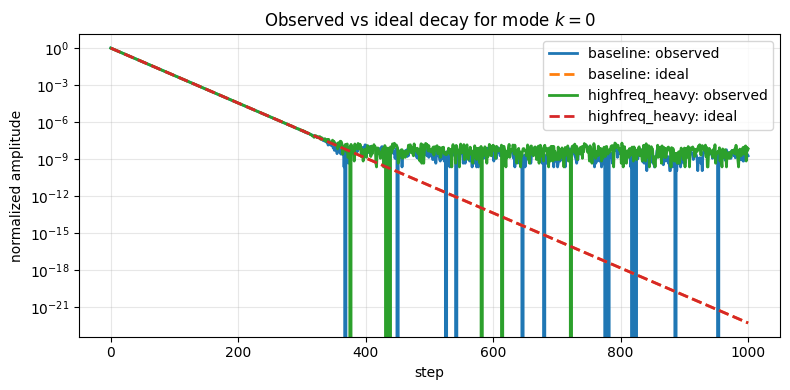

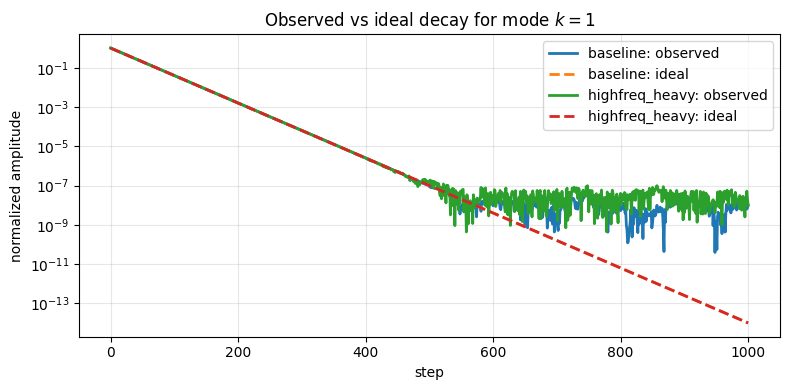

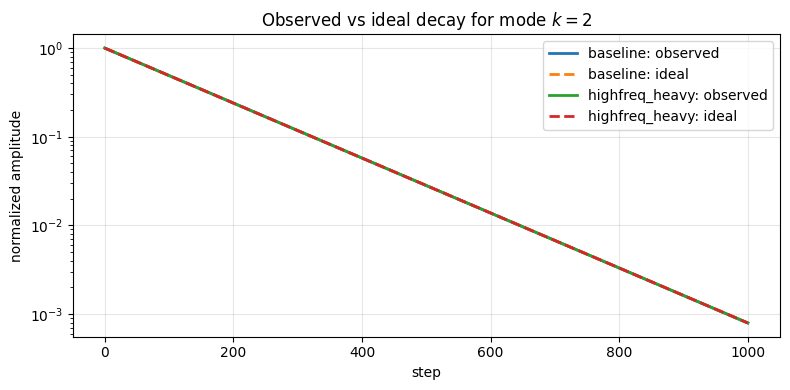

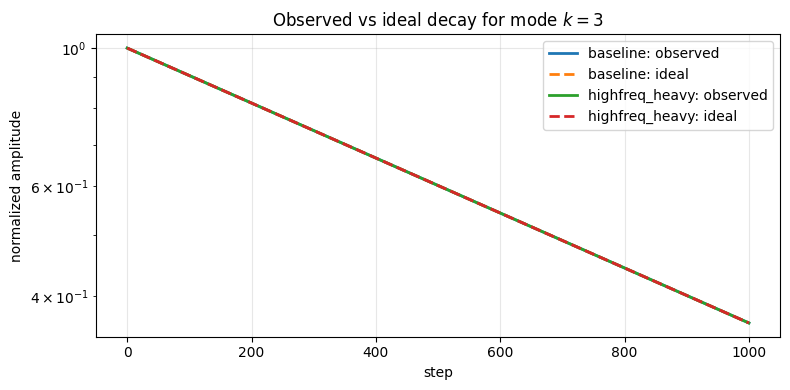

In [37]:
modes = [0, 1, 2, 3]
save_path = lambda k: plot_path / f"observed_vs_ideal_residual_decay_mode_{k}.png"

for k in modes:
    plt.figure(figsize=(8, 4))
    for label in ["baseline", "highfreq_heavy"]:
        obs = np.abs(np.asarray(A[label]["mode_projections"][f"cos_{k}"]))
        obs = obs / max(obs[0], 1e-14)

        cs = runs[label]["continuum_spectrum"]
        lam_map = {
            int(kk): float(lam)
            for kk, lam in zip(cs["ks_compare"], cs["lambda_disc_pred"])
        }
        eta = A[label]["eta"]
        pred = np.abs(1.0 - eta * lam_map[k]) ** np.arange(len(obs))

        plt.plot(obs, linewidth=2, label=f"{label}: observed")
        plt.plot(pred, "--", linewidth=2, label=f"{label}: ideal")

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("normalized amplitude")
    plt.title(rf"Observed vs ideal decay for mode $k={k}$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path(k), dpi=300)
    plt.show()

In [ ]:
modes = [0, 1, 2, 3]

print("Initial mode amplitudes:")
for label in ["baseline_shape", "highfreq_heavy"]:
    print(f"\n{label}")
    for k in modes:
        a0 = float(np.abs(A[label]["mode_projections"][f"cos_{k}"][0]))
        print(f"  k={k}: {a0:.6e}")

print("\nMax absolute error between observed and ideal normalized decay:")
for label in ["baseline_shape", "highfreq_heavy"]:
    print(f"\n{label}")
    cs = runs[label]["continuum_spectrum"]
    lam_map = {
        int(kk): float(lam)
        for kk, lam in zip(cs["ks_compare"], cs["lambda_disc_pred"])
    }
    eta = A[label]["eta"]

    for k in modes:
        obs = np.abs(np.asarray(A[label]["mode_projections"][f"cos_{k}"]))
        obs = obs / max(obs[0], 1e-14)

        pred = np.abs(1.0 - eta * lam_map[k]) ** np.arange(len(obs))
        err = np.max(np.abs(obs - pred))

        print(f"  k={k}: {err:.3e}")

Initial mode amplitudes:

baseline_shape
  k=0: 3.200000e+01
  k=1: 2.036468e+01
  k=2: 1.131371e+01
  k=3: 7.919599e+00

highfreq_heavy
  k=0: 3.200000e+01
  k=1: 7.919602e+00
  k=2: 2.036468e+01
  k=3: 3.167838e+01

Max absolute error between observed and ideal normalized decay:

baseline_shape
  k=0: 3.323e-07
  k=1: 5.696e-07
  k=2: 1.774e-06
  k=3: 1.070e-05

highfreq_heavy
  k=0: 2.885e-07
  k=1: 6.596e-07
  k=2: 1.682e-06
  k=3: 1.048e-05
